In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df_biens = pd.read_csv('BienImmobilier.csv')
df_communes = pd.read_csv('CodeCommune.csv')
df_type_biens = pd.read_csv('CodeTypeBien.csv')
df_type_voies = pd.read_csv('CodeTypeVoie.csv')

# Table de Biens

In [65]:
df_biens.head()

,id_bien,date_vente,valeur_bien,numero_voie,b_t_q,FK_id_type_voie,nom_voie,FK_id_commune,FK_id_type_bien,nbr_pieces,surface_terrain,surface_reelle,surface_carrez
0,1,2020-02-03,56000.0,190.0,A,0,CENTRALE,0,2,2,NaN,52,50.42
1,2,2020-01-02,165000.0,347.0,NaN,0,DU CHATEAU,1,2,3,NaN,48,48.22
2,3,2020-01-08,720000.0,58.0,NaN,1,DU MONT BLANC,2,2,6,NaN,130,130.80
3,4,2020-01-06,429250.0,140.0,NaN,0,DE L'ABBE JOLIVET,3,1,5,NaN,109,109.22
4,5,2020-01-07,220900.0,39.0,NaN,0,BUFFON,4,2,4,NaN,91,108.65


In [66]:
df_biens.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34169 entries, 0 to 34168
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_bien          34169 non-null  int64  
 1   date_vente       34169 non-null  object 
 2   valeur_bien      34151 non-null  float64
 3   numero_voie      34036 non-null  float64
 4   b_t_q            2174 non-null   object 
 5   FK_id_type_voie  34169 non-null  int64  
 6   nom_voie         34169 non-null  object 
 7   FK_id_commune    34169 non-null  int64  
 8   FK_id_type_bien  34169 non-null  int64  
 9   nbr_pieces       34169 non-null  int64  
 10  surface_terrain  253 non-null    float64
 11  surface_reelle   34169 non-null  int64  
 12  surface_carrez   34169 non-null  float64
dtypes: float64(4), int64(6), object(3)
memory usage: 3.4+ MB


In [67]:
df_biens.describe()

,id_bien,valeur_bien,numero_voie,FK_id_type_voie,FK_id_commune,FK_id_type_bien,nbr_pieces,surface_terrain,surface_reelle,surface_carrez
count,34169.00000,3.415100e+04,34036.000000,34169.000000,34169.000000,34169.000000,34169.000000,253.000000,34169.000000,34169.000000
mean,17085.00000,2.528471e+05,450.483429,4.026574,2009.368931,1.918318,2.616026,355.529644,56.724458,57.644624
std,9863.88501,3.252594e+05,1712.852166,9.272656,1051.410563,0.273884,1.222260,359.067670,29.881797,53.335621
min,1.00000,5.375000e+02,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.400000
25%,8543.00000,1.040000e+05,8.000000,0.000000,1054.000000,2.000000,2.000000,115.000000,35.000000,34.600000
50%,17085.00000,1.690000e+05,22.000000,0.000000,2288.000000,2.000000,3.000000,271.000000,53.000000,53.000000
75%,25627.00000,2.850000e+05,66.000000,2.000000,3011.000000,2.000000,3.000000,470.000000,72.000000,72.310000
max,34169.00000,9.000000e+06,9999.000000,79.000000,3214.000000,2.000000,11.000000,2670.000000,379.000000,5153.000000


#Analyse sur la colonne surface_terrain:
on a que 253 lignes, ce qui est très peu par rapport au reste.
donc il n'y a pas de terrain privatif.
 Les surfaces min est de 1m (erreur de saisie) et max est de 2670m.
 La moyenne des terrains est de 355m. Mais si on regarde, La moitié des terrains font moins de 255m.
 25% de surfaces sont en dessous de 115 et 75% sont en dessous de 470.


In [68]:
df_biens.isnull().sum()

,0
id_bien,0
date_vente,0
valeur_bien,18
numero_voie,133
b_t_q,31995
FK_id_type_voie,0
nom_voie,0
FK_id_commune,0
FK_id_type_bien,0
nbr_pieces,0


In [69]:
# 1. Conversion des types
df_biens['date_vente'] = pd.to_datetime(df_biens['date_vente'], errors='coerce')
df_biens['valeur_bien'] = pd.to_numeric(df_biens['valeur_bien'], errors='coerce')

In [70]:
#Remplacer les NaN par SANS dans la colonne b_t_q
df_biens['b_t_q'] = df_biens['b_t_q'].fillna('SANS')

In [71]:
# Création de la surface utile (Carrez si dispo, sinon Réelle)
df_biens['surface_utile'] = df_biens['surface_carrez'].fillna(df_biens['surface_reelle'])

In [72]:
#Surface Terrain Appartements à 0
mask_appt = df_biens['FK_id_type_bien'] == 1
df_biens.loc[mask_appt, 'surface_terrain'] = df_biens.loc[mask_appt, 'surface_terrain'].fillna(0)

Pour les maisons, on fera l'imputation après la jointure pour avoir le nom de la commune

In [73]:
df_biens.isnull().sum()

,0
id_bien,0
date_vente,0
valeur_bien,18
numero_voie,133
b_t_q,0
FK_id_type_voie,0
nom_voie,0
FK_id_commune,0
FK_id_type_bien,0
nbr_pieces,0


In [74]:
# je supprime les 18 lignes
df_biens = df_biens.dropna(subset=['valeur_bien'])
#Remplacer les numéros de voie manquants par 0
df_biens['numero_voie'] = df_biens['numero_voie'].fillna(0)

In [75]:
df_biens.duplicated().sum()

np.int64(0)

Table commune

In [76]:
df_communes.head()

,id_commune,commune,code_commune,code_postal,code_departement
0,0,SAINT-ETIENNE-DU-BOIS,350,1370.0,1
1,1,CHEVRY,103,1170.0,1
2,2,DIVONNE-LES-BAINS,143,1220.0,1
3,3,PERON,288,1630.0,1
4,4,VALSERHONE,33,1200.0,1


In [77]:
df_communes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3215 entries, 0 to 3214
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_commune        3215 non-null   int64  
 1   commune           3215 non-null   object 
 2   code_commune      3215 non-null   int64  
 3   code_postal       3214 non-null   float64
 4   code_departement  3215 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 125.7+ KB


In [78]:
df_communes.describe()

,id_commune,code_commune,code_postal
count,3215.000000,3215.000000,3214.000000
mean,1607.000000,221.228616,54160.834474
std,928.234884,174.568004,27911.208526
min,0.000000,1.000000,1090.000000
25%,803.500000,80.000000,33220.000000
50%,1607.000000,185.000000,56630.000000
75%,2410.500000,323.000000,77700.000000
max,3214.000000,899.000000,97490.000000


#Analyse
on remarque sur la colonne code_postal une ligne manquante
nombre de ligne 3214
25% de code postal sont en dessous de 33220 et 75% sont en dessous de 77700.
le min est 1090 et max 97490
la moyenne est 54160


In [79]:
df_communes.isnull().sum()

,0
id_commune,0
commune,0
code_commune,0
code_postal,1
code_departement,0


je constate que sur la colonne code_postal on a une ligne manquante

In [80]:
# Trouver la commune qui n'a pas de code postal
commune_vide = df_communes[df_communes['code_postal'].isnull()]
print(commune_vide[['id_commune', 'commune', 'code_departement']])

     id_commune  commune code_departement
658         658  AJACCIO               2A


In [81]:
df_communes.loc[df_communes['code_postal'].isnull(), 'code_postal'] = '20000'

/tmp/ipykernel_211/471966689.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '20000' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_communes.loc[df_communes['code_postal'].isnull(), 'code_postal'] = '20000'


In [82]:
# on filtre par son index 658 pour verifier
df_communes.loc[658]

,658
id_commune,658
commune,AJACCIO
code_commune,4
code_postal,20000
code_departement,2A


In [83]:
df_communes.duplicated().sum()

np.int64(0)

Table type de bien

In [84]:
df_type_biens.head()

,id_type_bien,type_bien
0,1,Maison
1,2,Appartement


In [85]:
df_type_biens.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id_type_bien  2 non-null      int64 
 1   type_bien     2 non-null      object
dtypes: int64(1), object(1)
memory usage: 164.0+ bytes


In [86]:
df_type_biens.describe()

,id_type_bien
count,2.000000
mean,1.500000
std,0.707107
min,1.000000
25%,1.250000
50%,1.500000
75%,1.750000
max,2.000000


#Analyse
Il y a 2 lignes (appartement et maison).
la moyenne est 1.5 egale  a la mediane



In [87]:
df_type_biens.isnull().sum()

,0
id_type_bien,0
type_bien,0


Table type de voies

In [88]:
df_type_voies.head()

,id_type_voie,type_voie
0,0,RUE
1,1,AV
2,2,ALL
3,3,RTE
4,4,CRS


In [89]:
df_type_voies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id_type_voie  80 non-null     int64 
 1   type_voie     79 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.4+ KB


In [90]:
df_type_voies.describe()

,id_type_voie
count,80.0000
mean,39.5000
std,23.2379
min,0.0000
25%,19.7500
50%,39.5000
75%,59.2500
max,79.0000


#Analyse
il ya 80 lignes
la moyennes est 39.5 egale a la medaine


In [91]:
df_type_voies.isnull().sum()

,0
id_type_voie,0
type_voie,1


il manque une ligne dans la colonne type_voie du coup je vais la remplace par voie inconnue

In [92]:
df_type_voies['type_voie'] = df_type_voies['type_voie'].fillna('Voie inconnue')

In [93]:
df_type_voies.duplicated().sum()

np.int64(0)

In [94]:
# Jointures successives
df_final = pd.merge(df_biens, df_communes, left_on='FK_id_commune', right_on='id_commune')
df_final = pd.merge(df_final, df_type_biens, left_on='FK_id_type_bien', right_on='id_type_bien')

# Prix au m2
df_final['prix_m2'] = df_final['valeur_bien'] / df_final['surface_reelle']

In [95]:
df_final.head()

,id_bien,date_vente,valeur_bien,numero_voie,b_t_q,FK_id_type_voie,nom_voie,FK_id_commune,FK_id_type_bien,nbr_pieces,...,surface_carrez,surface_utile,id_commune,commune,code_commune,code_postal,code_departement,id_type_bien,type_bien,prix_m2
0,1,2020-02-03,56000.0,190.0,A,0,CENTRALE,0,2,2,...,50.42,50.42,0,SAINT-ETIENNE-DU-BOIS,350,1370.0,1,2,Appartement,1076.923077
1,2,2020-01-02,165000.0,347.0,SANS,0,DU CHATEAU,1,2,3,...,48.22,48.22,1,CHEVRY,103,1170.0,1,2,Appartement,3437.500000
2,3,2020-01-08,720000.0,58.0,SANS,1,DU MONT BLANC,2,2,6,...,130.80,130.80,2,DIVONNE-LES-BAINS,143,1220.0,1,2,Appartement,5538.461538
3,4,2020-01-06,429250.0,140.0,SANS,0,DE L'ABBE JOLIVET,3,1,5,...,109.22,109.22,3,PERON,288,1630.0,1,1,Maison,3938.073394
4,5,2020-01-07,220900.0,39.0,SANS,0,BUFFON,4,2,4,...,108.65,108.65,4,VALSERHONE,33,1200.0,1,2,Appartement,2427.472527


In [96]:
# Pour les maisons, on remplit avec la médiane de la commune
df_final['surface_terrain'] = df_final.groupby('commune')['surface_terrain'].transform(lambda x: x.fillna(x.median()))

In [97]:
# Si certaines communes n'ont vraiment aucune donnée de terrain, on met la médiane globale
df_final['surface_terrain'] = df_final['surface_terrain'].fillna(df_final['surface_terrain'].median())

In [98]:
df_final.isnull().sum()

,0
id_bien,0
date_vente,0
valeur_bien,0
numero_voie,0
b_t_q,0
FK_id_type_voie,0
nom_voie,0
FK_id_commune,0
FK_id_type_bien,0
nbr_pieces,0


In [99]:
df_final.duplicated().sum()

np.int64(0)

In [100]:
# REQUÊTE 1 : Nombre d'appartements vendus au 1er semestre 2020 (Janvier à Juin)
requete_1 = df_final[(df_final['type_bien'] == 'Appartement') & (df_final['date_vente'].dt.month <= 6)].shape[0]

# REQUÊTE 2 : Proportion des ventes par nombre de pièces
requete_2 = df_final['nbr_pieces'].value_counts(normalize=True).sort_index() * 100

# REQUÊTE 3 : Top 10 des départements les plus chers (Prix au m2 moyen)
requete_3 = df_final.groupby('code_departement').apply(lambda x: x['valeur_bien'].sum() / x['surface_utile'].sum()).nlargest(10)

# REQUÊTE 4 : Prix moyen au m2 d'une maison en Île-de-France
idf_codes = ['75', '77', '78', '91', '92', '93', '94', '95']
maisons_idf = df_final[(df_final['type_bien'] == 'Maison') & (df_final['code_departement'].isin(idf_codes))]
requete_4 = maisons_idf['valeur_bien'].sum() / maisons_idf['surface_utile'].sum()

# REQUÊTE 5 : Liste des 10 appartements les plus chers (Valeur foncière)
requete_5 = df_final[df_final['type_bien'] == 'Appartement'].nlargest(10, 'valeur_bien')[['valeur_bien', 'code_departement', 'commune']]

# REQUÊTE 6 : Écart de prix au m2 entre un 2 pièces et un 3 pièces
p2 = df_final[df_final['nbr_pieces'] == 2]['valeur_bien'].sum() / df_final[df_final['nbr_pieces'] == 2]['surface_utile'].sum()
p3 = df_final[df_final['nbr_pieces'] == 3]['valeur_bien'].sum() / df_final[df_final['nbr_pieces'] == 3]['surface_utile'].sum()
requete_6 = ((p3 - p2) / p2) * 100

# REQUÊTE 7 : Évolution du nombre de ventes entre le T1 (Trimestre 1) et le T2 (Trimestre 2) 2020
t1 = df_final[df_final['date_vente'].dt.quarter == 1].shape[0]
t2 = df_final[df_final['date_vente'].dt.quarter == 2].shape[0]
requete_7 = ((t2 - t1) / t1) * 100

# REQUÊTE 8 : Communes avec une hausse des ventes de plus de 20% entre T1 et T2
evol_communes = df_final.groupby(['commune', df_final['date_vente'].dt.quarter]).size().unstack(fill_value=0)
# On s'assure que les colonnes 1 (T1) et 2 (T2) existent
evol_communes['progression'] = ((evol_communes[2] - evol_communes[1]) / evol_communes[1]) * 100
requete_8 = evol_communes[evol_communes['progression'] > 20].sort_values('progression', ascending=False)

# REQUÊTE 9 : Top 3 des communes les plus chères (Dept: 06, 13, 33, 59, 69)
depts_cibles = ['06', '13', '33', '59', '69']
df_q9 = df_final[df_final['code_departement'].isin(depts_cibles)]
# Calcul du prix moyen par département (info contextuelle)
requete_9_A = df_q9.groupby('code_departement')['prix_m2'].mean().sort_values(ascending=False)
# Top 3 des communes par département
requete_9_B = df_q9.sort_values(['code_departement', 'valeur_bien'], ascending=[True, False]).groupby('code_departement').head(3)


/tmp/ipykernel_211/4095663430.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  requete_3 = df_final.groupby('code_departement').apply(lambda x: x['valeur_bien'].sum() / x['surface_utile'].sum()).nlargest(10)


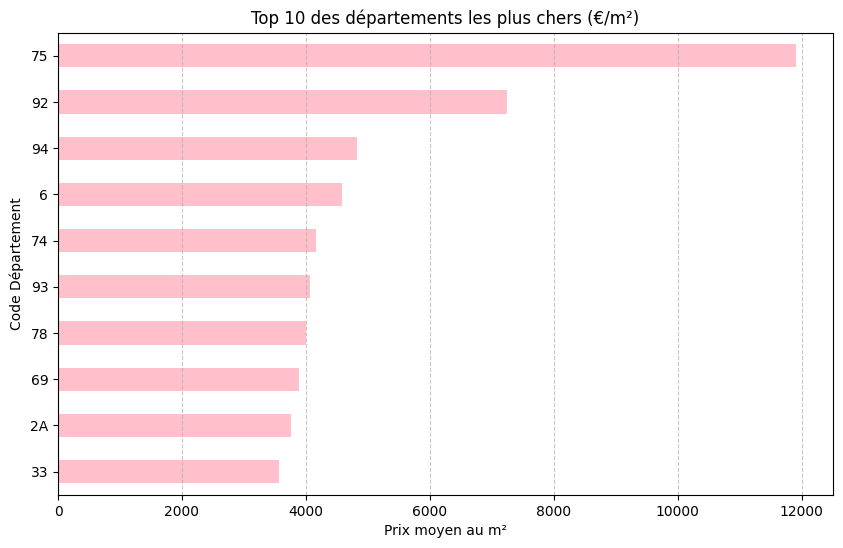

In [101]:
plt.figure(figsize=(10,6))
requete_3.sort_values().plot(kind='barh', color='pink')
plt.title('Top 10 des départements les plus chers (€/m²)')
plt.xlabel('Prix moyen au m²')
plt.ylabel('Code Département')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

ce graphique montre les departement le plus chers nous avons 75 ensuite 92 ont de prix eleves par rapport aux autres departement

/tmp/ipykernel_211/481998936.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventes_trimestre.index, y=ventes_trimestre.values, palette='viridis')


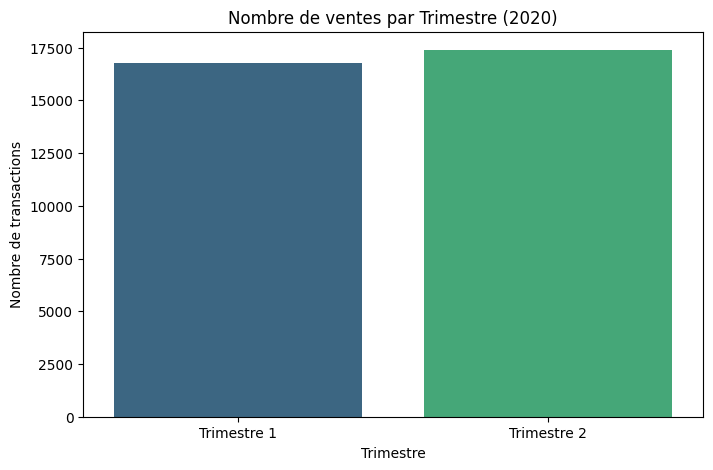

In [102]:
ventes_trimestre = df_final['date_vente'].dt.quarter.value_counts().sort_index()
plt.figure(figsize=(8,5))
sns.barplot(x=ventes_trimestre.index, y=ventes_trimestre.values, palette='viridis')
plt.title('Nombre de ventes par Trimestre (2020)')
plt.xlabel('Trimestre')
plt.ylabel('Nombre de transactions')
plt.xticks([0, 1], ['Trimestre 1', 'Trimestre 2'])
plt.show()

ce graphique nous montre la saisonnalité du marché.
on constate que nombre de ventes augmente sur le trimestre 2

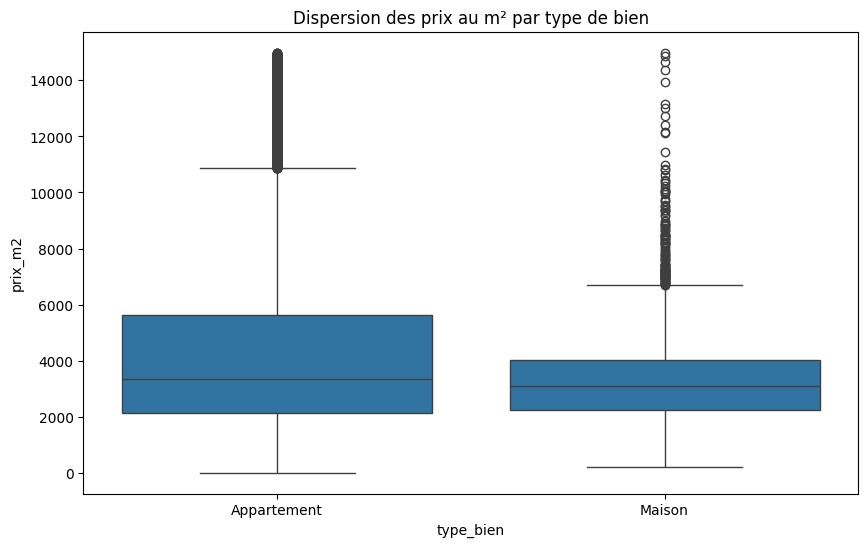

In [103]:
plt.figure(figsize=(10,6))
sns.boxplot(x='type_bien', y='prix_m2', data=df_final[df_final['prix_m2'] < 15000])
plt.title('Dispersion des prix au m² par type de bien')
plt.show()

 Appartement :
 Le min est vers 0 €/m².
 Les appartements coûtent globalement plus cher que les maisons.
 50% des appartements coûtent moins de 3400 €/m².
 75% des appartement coûtent moins de 5600 €/m².
 25% des appartement coûtent moins de 2100 €/m².
 Le max est vers 11 000 €/m². Au-delà, ce sont des valeurs atypiques.

maison :
Le min est vers 0 €/m².
25% Environ 2 300 €/m².

50% Environ 3 100 €/m².

75% : Environ 4 100 €/m².
 Le max est vers 6500 €/m². Au-delà, ce sont des valeurs atypiques.

L'analyse clé : On voit que 75% des maisons coûtent moins de 4 100 €/m², alors que pour les appartements, ce seuil est beaucoup plus haut (5 700 €/m²), donc les appartements sont plus chers que les maisons.